In [23]:
"""
Of the top 200 runs, plot the mean and slope of fungi uptake of nutrients
"""
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
PREFIX = "UQ_20240311_1"
if PREFIX == 'UQ_20240311_1':
    # Down-select the runs because it is impossible to finish processing
    # all 4000 runs in reasonable amount of time
    subset_ensemble = \
        [2472, 1476, 2954, 1082, 2537, 2879, 1741, 3207, 2788,  848,  598, 2055, 3426, 2552, 
         3346, 3144, 3550, 2339,  760, 2337,  638, 1198,  883, 2047, 2728, 3211, 3563, 2722, 
         2721, 2558,  743,  318, 2364, 3412, 1790,  769, 2717, 1568, 1409, 2714, 3000, 3512, 
         3333,   44, 3576, 1171,  323,  974, 2900, 1304, 1599,   52, 1397,  547, 3824, 2309, 
           57, 3503, 2708,  542, 3947, 3944, 1811, 1564, 3275, 1165, 3825, 2396, 2706, 2568, 
          826,  534, 2401, 1390,   75,   76, 1679, 1223, 1381,  526,  523, 1154,  663,   84, 
         3923, 2947, 3268, 3920, 3265,  331,   91, 2498, 2685, 1852, 3158, 1095, 2955,  667, 
         1563, 2267, 1375, 3760,  501, 3907,  498, 1535,  813, 2820, 3639, 1368, 1367, 2575, 
         3085, 2868, 2914, 2249,  228, 3896, 3327,  488, 2864, 2969,  905,  674,  225, 2590, 
         3650, 2594,  129,  808, 2663, 2221, 1994, 3063, 1278, 1059, 2596,  368, 1888, 1009, 
         1110,  370,  143, 1979, 1017,  688,  804,  447, 2651, 3841, 1916, 1637,  207, 2643, 
          435, 1057, 2205, 1336,  205, 1628, 1274, 3321, 2851, 3325, 1113, 3844, 1951,  168, 
         1548, 3392, 1953, 1955, 3456,  174,  175, 1321, 2194, 3714, 2187,  398, 1051,  394, 
         2905, 3223, 1464, 2174,  193, 2172, 1115, 2532,  632,  858, 3559, 1056, 1144,  932, 
          217, 2711, 1812, 2907]
    subset_rmse_tot = [1.224585, 1.240733, 1.230192, 1.250681, 1.252565, 1.235771, 1.228996, 
                       1.217439, 1.252295, 1.218619, 1.230345, 1.252523, 1.223413, 1.243316, 
                       1.182216, 1.222385, 1.22022, 1.24851, 1.231392, 1.22692, 1.23396, 1.230414,
                       1.250434, 1.229888, 1.243783, 1.240161, 1.245163, 1.252407, 1.240203,
                       1.248313, 1.24634, 1.250144, 1.245104, 1.253617, 1.242027, 1.238939, 
                       1.213102, 1.221166, 1.219989, 1.230752, 1.20699, 1.251477, 1.240561,
                       1.240659, 1.219789, 1.249519, 1.244128, 1.249529, 1.251438, 1.234603, 
                       1.235186, 1.204343, 1.2274, 1.243076, 1.233495, 1.213853, 1.218598, 
                       1.246717, 1.25162, 1.229183, 1.247239, 1.242623, 1.221398, 1.221753, 
                       1.249341, 1.246968, 1.241515, 1.22435, 1.208708, 1.249386, 1.223204, 
                       1.236542, 1.234473, 1.229315, 1.234968, 1.222112, 1.240576, 1.22576, 
                       1.229368, 1.252011, 1.226191, 1.230007, 1.250512, 1.211753, 1.227046, 
                       1.241543, 1.252582, 1.253719, 1.228906, 1.246326, 1.240365, 1.232856, 
                       1.246349, 1.250899, 1.235942, 1.249019, 1.245916, 1.246463, 1.243699, 
                       1.220656, 1.240464, 1.252036, 1.233648, 1.226895, 1.241595, 1.23718, 
                       1.23917, 1.221484, 1.229877, 1.221967, 1.23569, 1.2361, 1.251507, 1.232188,
                       1.229936, 1.23805, 1.233871, 1.235509, 1.223309, 1.238609, 1.254216, 
                       1.242076, 1.225616, 1.244603, 1.244494, 1.246089, 1.251217, 1.247726, 
                       1.24534, 1.253655, 1.235808, 1.243618, 1.250829, 1.230568, 1.239333, 
                       1.238602, 1.249253, 1.223538, 1.244491, 1.201692, 1.249925, 1.232152, 
                       1.231129, 1.231622, 1.253521, 1.239719, 1.238963, 1.251096, 1.254594, 
                       1.242531, 1.194599, 1.213384, 1.253682, 1.231955, 1.208011, 1.248141, 
                       1.253581, 1.249112, 1.234495, 1.235199, 1.250665, 1.248, 1.212153, 1.242949,
                       1.233914, 1.229906, 1.237622, 1.227236, 1.236436, 1.245009, 1.241553, 
                       1.238577, 1.236828, 1.246891, 1.253868, 1.233851, 1.24768, 1.230299, 
                       1.23261, 1.249445, 1.249949, 1.252419, 1.253927, 1.24273, 1.24875, 1.252968,
                       1.253139, 1.252961, 1.251627, 1.254717, 1.254845, 1.25508, 1.255352, 
                       1.255148, 1.254769, 1.255415, 1.254828, 1.255627, 1.255704, 1.256199]

elif PREFIX == 'UQ_20240311_2':
    subset_ensemble = [1312,981,3517,3473,1682,360,3452,432,461,3403,11,3393,343,3375,
                       1649,1645,17,3553,502,3332,541,3276,3275,316,582,603,3218,1605,
                       1774,3607,3958,640,3157,3103,35,1578,708,3054,3636,749,3650,1554,
                       2964,1857,2944,253,3656,801,1870,2924,820,1518,2901,845,2888,1912,
                       855,1495,2863,2835,2793,2786,1966,1465,1460,211,1451,931,935,938,
                       940,2725,2011,1425,1421,989,2688,1013,2606,3788,1088,2525,2521,2462,
                       2417,136,2355,133,89,2348,2269,1246,3844,1258,1293,2118,2175,2203,
                       3509,1228,2788,2776,1998,48,3733,3032,1289,108,709,990,4,3772,
                       3194,2548,2053,3306,3523,2482,2418,2386,3416,1694,221,3132,23,1651,
                       3718,2820,492,501,1639,3818,2074,2072,3811,874,1917,847,1302,2768,
                       2391,2889,841,3663,3729,2106,3454,959,1731,150,754,413,3314,3472,
                       2496,2507,1839,1627,1622,2713,604,2534,720,3752,1075,1762,1561,1679,
                       3381,984,2033,3494,1018,291,1833,3427,1975,86,2396,3348,411,2851,
                       525,329,1262,1853,2679,1979,1255,2363,3364,3318,3496,491,292,1208,
                       2750,1003,1166,8]
    subset_rmse_tot = [[1.142977, 1.23348 , 1.243083, 1.243011, 1.209739, 1.203076, 1.171134, 
                        1.218585, 1.239115, 1.144304, 1.190585, 1.229764, 1.210447, 1.230689, 
                        1.118924, 1.21497 , 1.208   , 1.191768, 1.204697, 1.215292, 1.210056, 
                        1.242243, 1.189185, 1.218033, 1.226687, 1.229877, 1.156666, 1.151804, 
                        1.234775, 1.147287, 1.206425, 1.182575, 1.142733, 1.21472 , 1.137168, 
                        1.166583, 1.102534, 1.175769, 1.224266, 1.243965, 1.237189, 1.210955, 
                        1.17093 , 1.209972, 1.2059  , 1.204591, 1.243818, 1.191225, 1.102663, 
                        1.247243, 1.234123, 1.18857 , 1.235862, 1.182879, 1.192974, 1.185721, 
                        1.209123, 1.171548, 1.229796, 1.214838, 1.154475, 1.104587, 1.127227, 
                        1.242926, 1.227571, 1.152424, 1.14473 , 1.149165, 1.121795, 1.218975, 
                        1.216166, 1.205943, 1.21218 , 1.205844, 1.174553, 1.246201, 1.193857, 
                        1.241841, 1.235514, 1.242925, 1.245392, 1.246892, 1.158052, 1.132691, 
                        1.221881, 1.245543, 1.145133, 1.226477, 1.222131, 1.234543, 1.084374, 
                        1.222111, 1.236061, 1.246017, 1.138383, 1.230884, 1.231832, 1.240126, 
                        1.248134, 1.255806, 1.253954, 1.253689, 1.254944, 1.256307, 1.252217, 
                        1.25599 , 1.256474, 1.248149, 1.25025 , 1.257833, 1.257491, 1.253982, 
                        1.253042, 1.249966, 1.251937, 1.250441, 1.251269, 1.256933, 1.254452, 
                        1.250513, 1.25651 , 1.252888, 1.257953, 1.272428, 1.274587, 1.273982, 
                        1.273578, 1.271382, 1.262469, 1.273911, 1.276432, 1.261328, 1.263093, 
                        1.258433, 1.268881, 1.266461, 1.268642, 1.268679, 1.259082, 1.262986, 
                        1.275576, 1.278352, 1.275578, 1.265786, 1.262235, 1.27663 , 1.259826, 
                        1.278568, 1.275157, 1.273798, 1.260585, 1.262232, 1.278339, 1.266844, 
                        1.262077, 1.269402, 1.269227, 1.27833 , 1.27551 , 1.277692, 1.263936, 
                        1.264038, 1.2658  , 1.277372, 1.272021, 1.266346, 1.266035, 1.26857 , 
                        1.260294, 1.276711, 1.259609, 1.261318, 1.259657, 1.263307, 1.276619, 
                        1.27894 , 1.280263, 1.279338, 1.281707, 1.28004 , 1.281031, 1.281286, 
                        1.283073, 1.27899 , 1.280095, 1.281409, 1.281661, 1.281703, 1.283062, 
                        1.283077, 1.283538, 1.283259, 1.283389, 1.283674, 1.283718, 1.284318, 
                        1.28446 , 1.284474, 1.284555, 1.2859  ]]

index = pd.MultiIndex.from_product([['amb', 'elev'], ['N','P'],
                                    ['Spruce','Tamarack','Shrub'],
                                    ['min froot','min fungi','org fungi']])

In [25]:
# Read the N & P uptake fractions
N = len(subset_ensemble)
BLOCK = 4
niter = int(N / BLOCK)
collection = np.full([N, 2, 36], np.nan)
for b in range(niter):
    temp = np.load(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                                'extract', PREFIX, f'ensemble_fungifrac_part{b:03g}.bin'),
                   allow_pickle=True)
    collection[(b*BLOCK):((b+1)*BLOCK), :, :] = temp

collection_mean = pd.DataFrame(collection[:, 0, :], columns = index, index = subset_ensemble)
collection_slope = pd.DataFrame(collection[:, 1, :], columns = index, index = subset_ensemble)

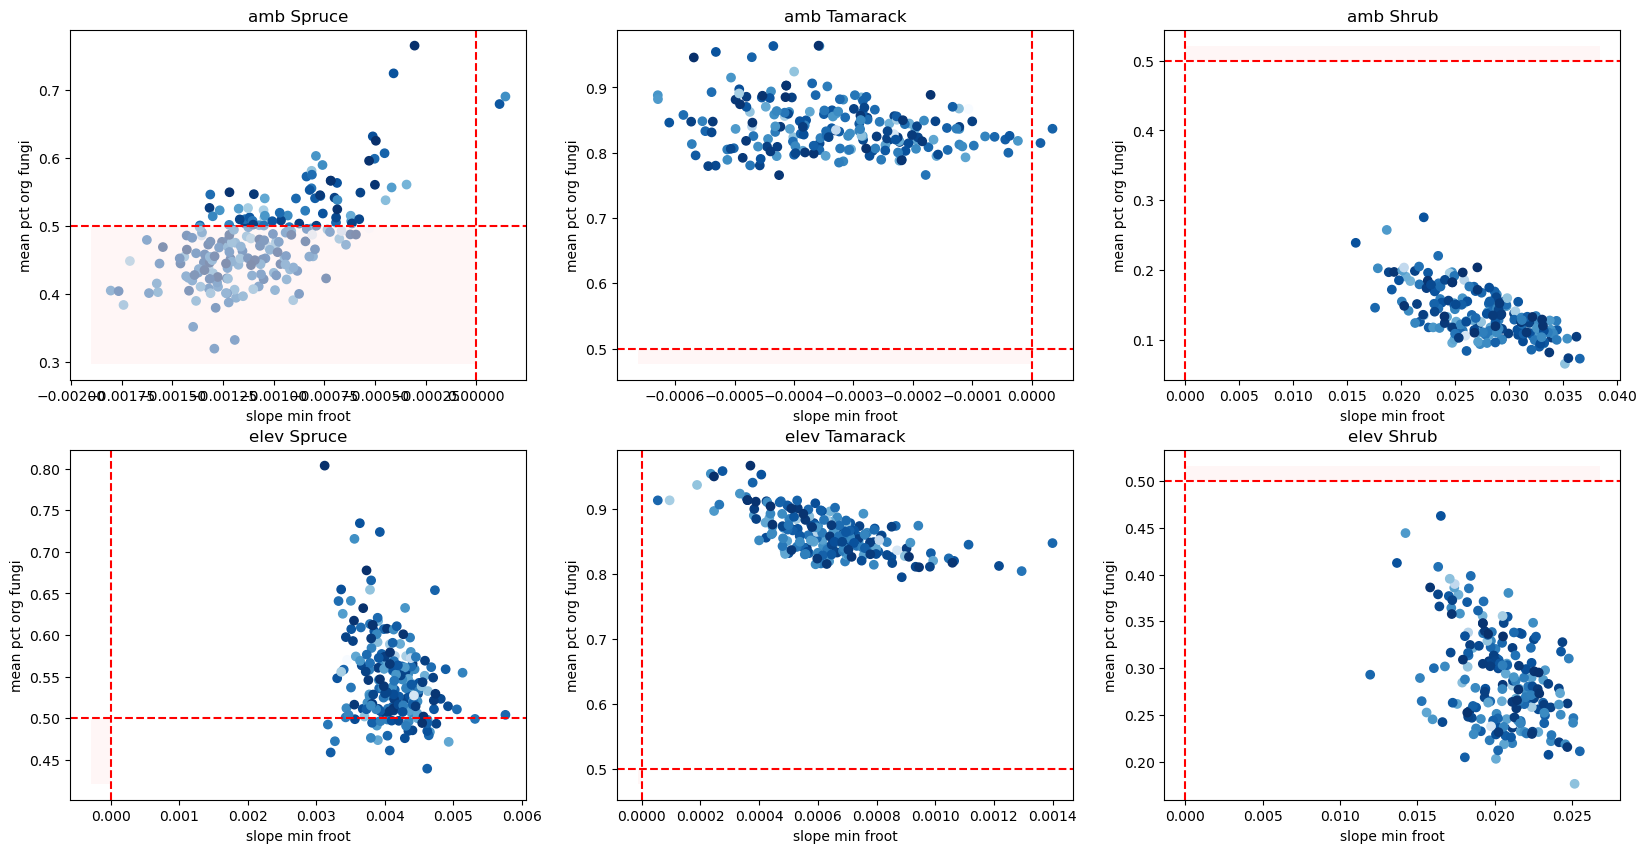

In [26]:
# froot uptake: should have an slightly negative slope for tree,
#                                       positive           shrub
# org fungi: should be relatively small for tree, large for shrub
nu = 'N'
fig, axes = plt.subplots(2, 3, figsize = (20, 10))
for i, co2 in enumerate(['amb', 'elev']):
    for j, pft in enumerate(['Spruce', 'Tamarack', 'Shrub']):
        ax = axes[i, j]
        x = collection_slope.loc[:, (co2, nu, pft, 'min froot')]
        y = (collection_mean.loc[:, (co2, nu, pft, 'org fungi')] + \
             collection_mean.loc[:, (co2, nu, pft, 'min fungi')]) / \
            (collection_mean.loc[:, (co2, nu, pft, 'org fungi')].values + \
             collection_mean.loc[:, (co2, nu, pft, 'min fungi')].values + \
             collection_mean.loc[:, (co2, nu, pft, 'min froot')].values)
        ax.scatter(x, y, c = subset_rmse_tot, cmap = 'Blues')
        ax.set_title(f'{co2} {pft}')
        ax.axvline(0, ls = '--', color = 'r')
        ax.axhline(0.5, ls = '--', color = 'r')
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        if pft == 'Shrub':
            # x > 0, y > 0.5
            ax.fill_between([0, xlim[1]], 0.5, ylim[1], facecolor='#FFEEEE', alpha=0.5)
        else:
            ax.fill_between([xlim[0], 0], ylim[0], 0.5, facecolor='#FFEEEE', alpha=0.5)
        ax.set_xlabel('slope min froot')
        ax.set_ylabel('mean pct org fungi')

In [27]:
x.shape

(200,)